# 1 Likelihood Based Analysis of the 21-cm Power Spectrum
## a) PCA

In [ ]:
%load_ext autoreload
%autoreload 2

import numpy as np  
import matplotlib.pyplot as plt
import optuna
import torch
import pickle
import tqdm
import copy
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from pathlib import Path
from torch import nn, optim

In [ ]:
from utils.general import load_splits, set_seed

set_seed(1701)
data_dir = Path("simulations")
raw_data = load_splits(data_dir)

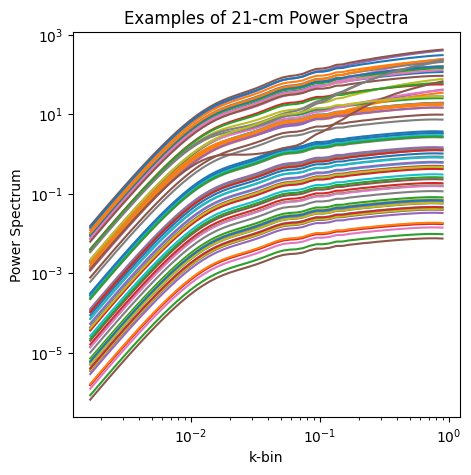

In [128]:
from utils.basic_plots import plot_power_spectra

plot_power_spectra(raw_data)

- We must normalise the training parameters as they can have different scales with respect to one another. We don't want to bias the trained NN based on the various input scales so we can scale them using a StandardScaler, which brings the mean to 0 and variance to 1.
- Each power spectrum mode has a different scale. For PCA, we want to find meaningful variations, not just the largest magnitude variations, which can be a result of different component scales. A component can have little relative variance in its axis but a huge absolute variance because of scale. As such, we normalise our power spectra as well.
- Since the power spectra vary across several orders of magnitude, it is prudent to work with the logarithm.

In [141]:
from utils.preprocess import preprocess
processed = preprocess(raw_data, n_comp=6, log_power=True)

- Now we apply PCA on this data

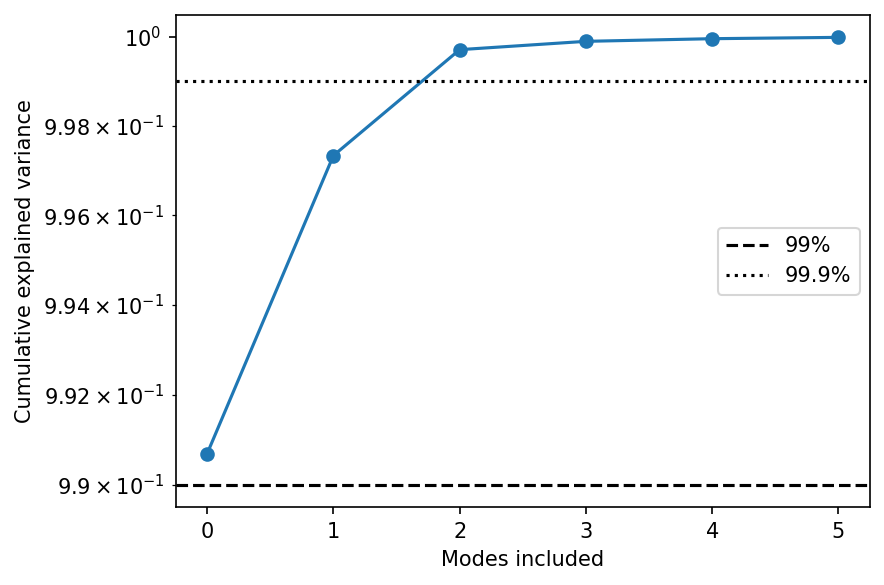

99.000% threshold explained by first 1 components
99.900% threshold explained by first 3 components
99.990% threshold explained by first 5 components


In [142]:
from utils.basic_plots import evr_stats

evr_stats(processed)

- This tells us that the first three eigenvectors are all we need to describe a significant majority of the variance in the data.  It will be valid to compress the training data down using just the first three eigenvectors. 
- However, the explained variance does not correspond directly to emulator accuracy. There are a few more factors to consider:
    - The emulated likelihood may depend on some rare features which only appear in the extremes of some parameter. Because the feature is rare, this leaves a very low variance footprint in the PCA.
    - The emulated likelihood may depend on some small scale feature which looks very small in absolute variance terms.
    - The training set may not be completely representative. Some features appearing in the validation set might not appear here.
- It would not cost too much more to perform the analysis with a few more components for safety.

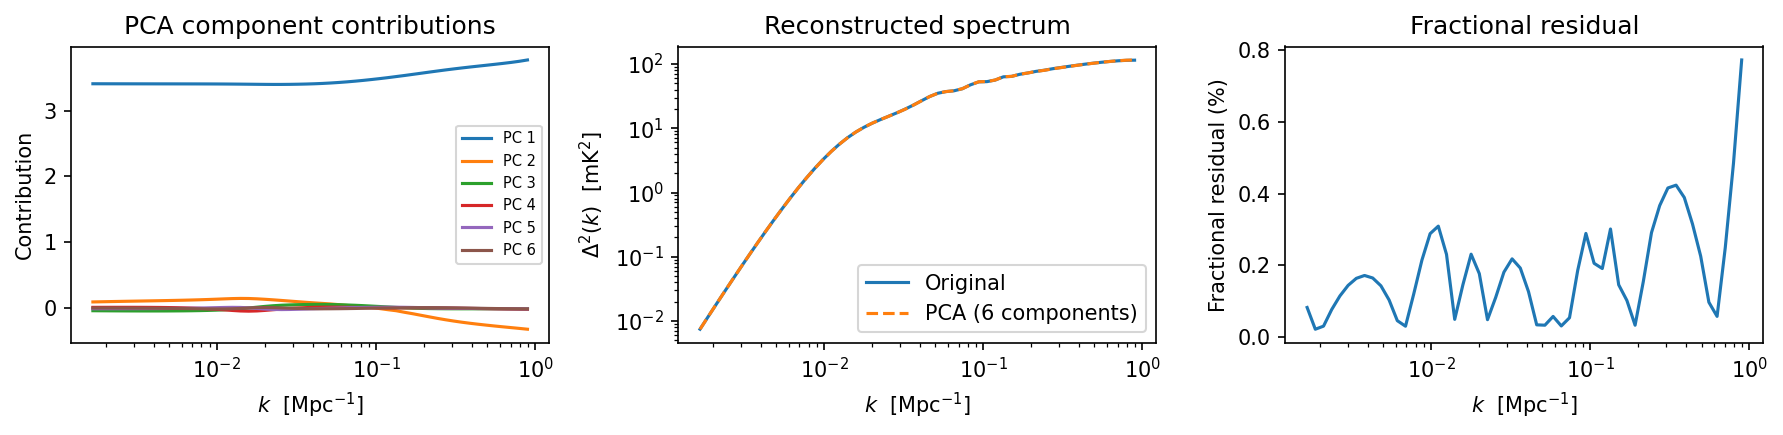

In [143]:
n_comp = 6
from utils.basic_plots import plot_reconstructed_train
_ = plot_reconstructed_train(processed, n_comp=n_comp, plot=True, idx=0)

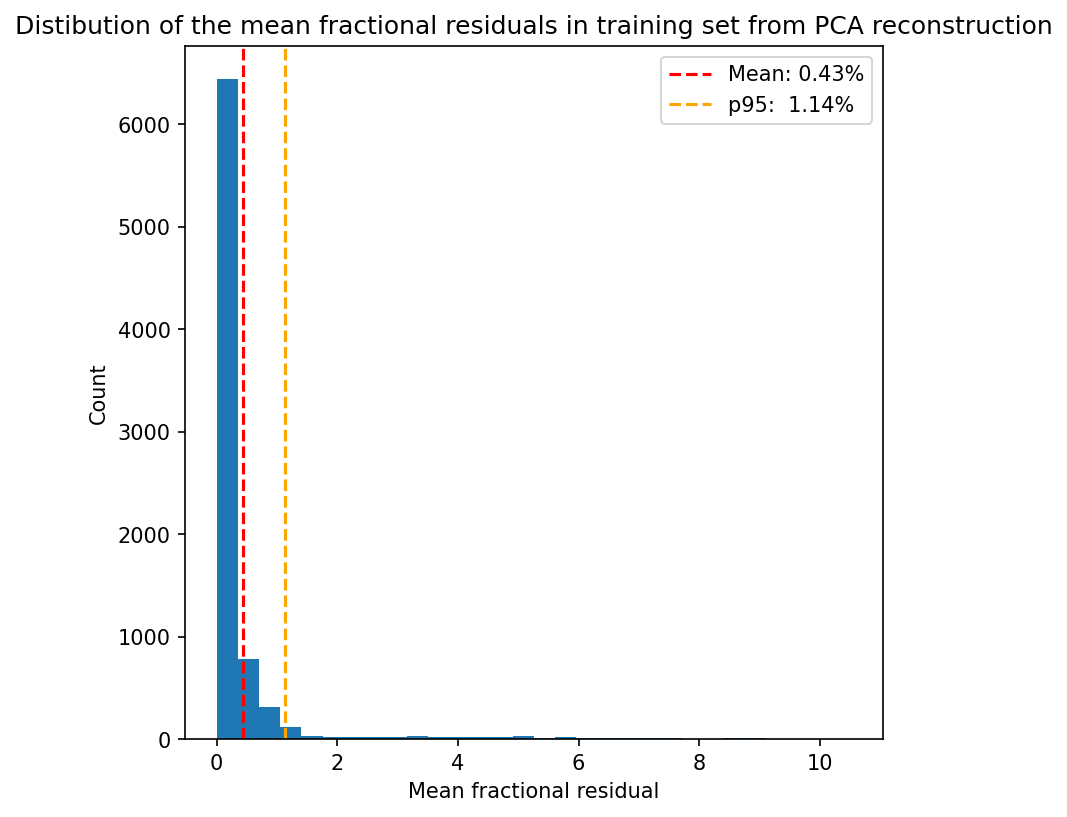

In [146]:
# Plot fractional residual distribution for PCA reconstruction on training set
from utils.basic_plots import pca_fractional_residual
_ = pca_fractional_residual(processed, n_comp=n_comp)

# b) NN 



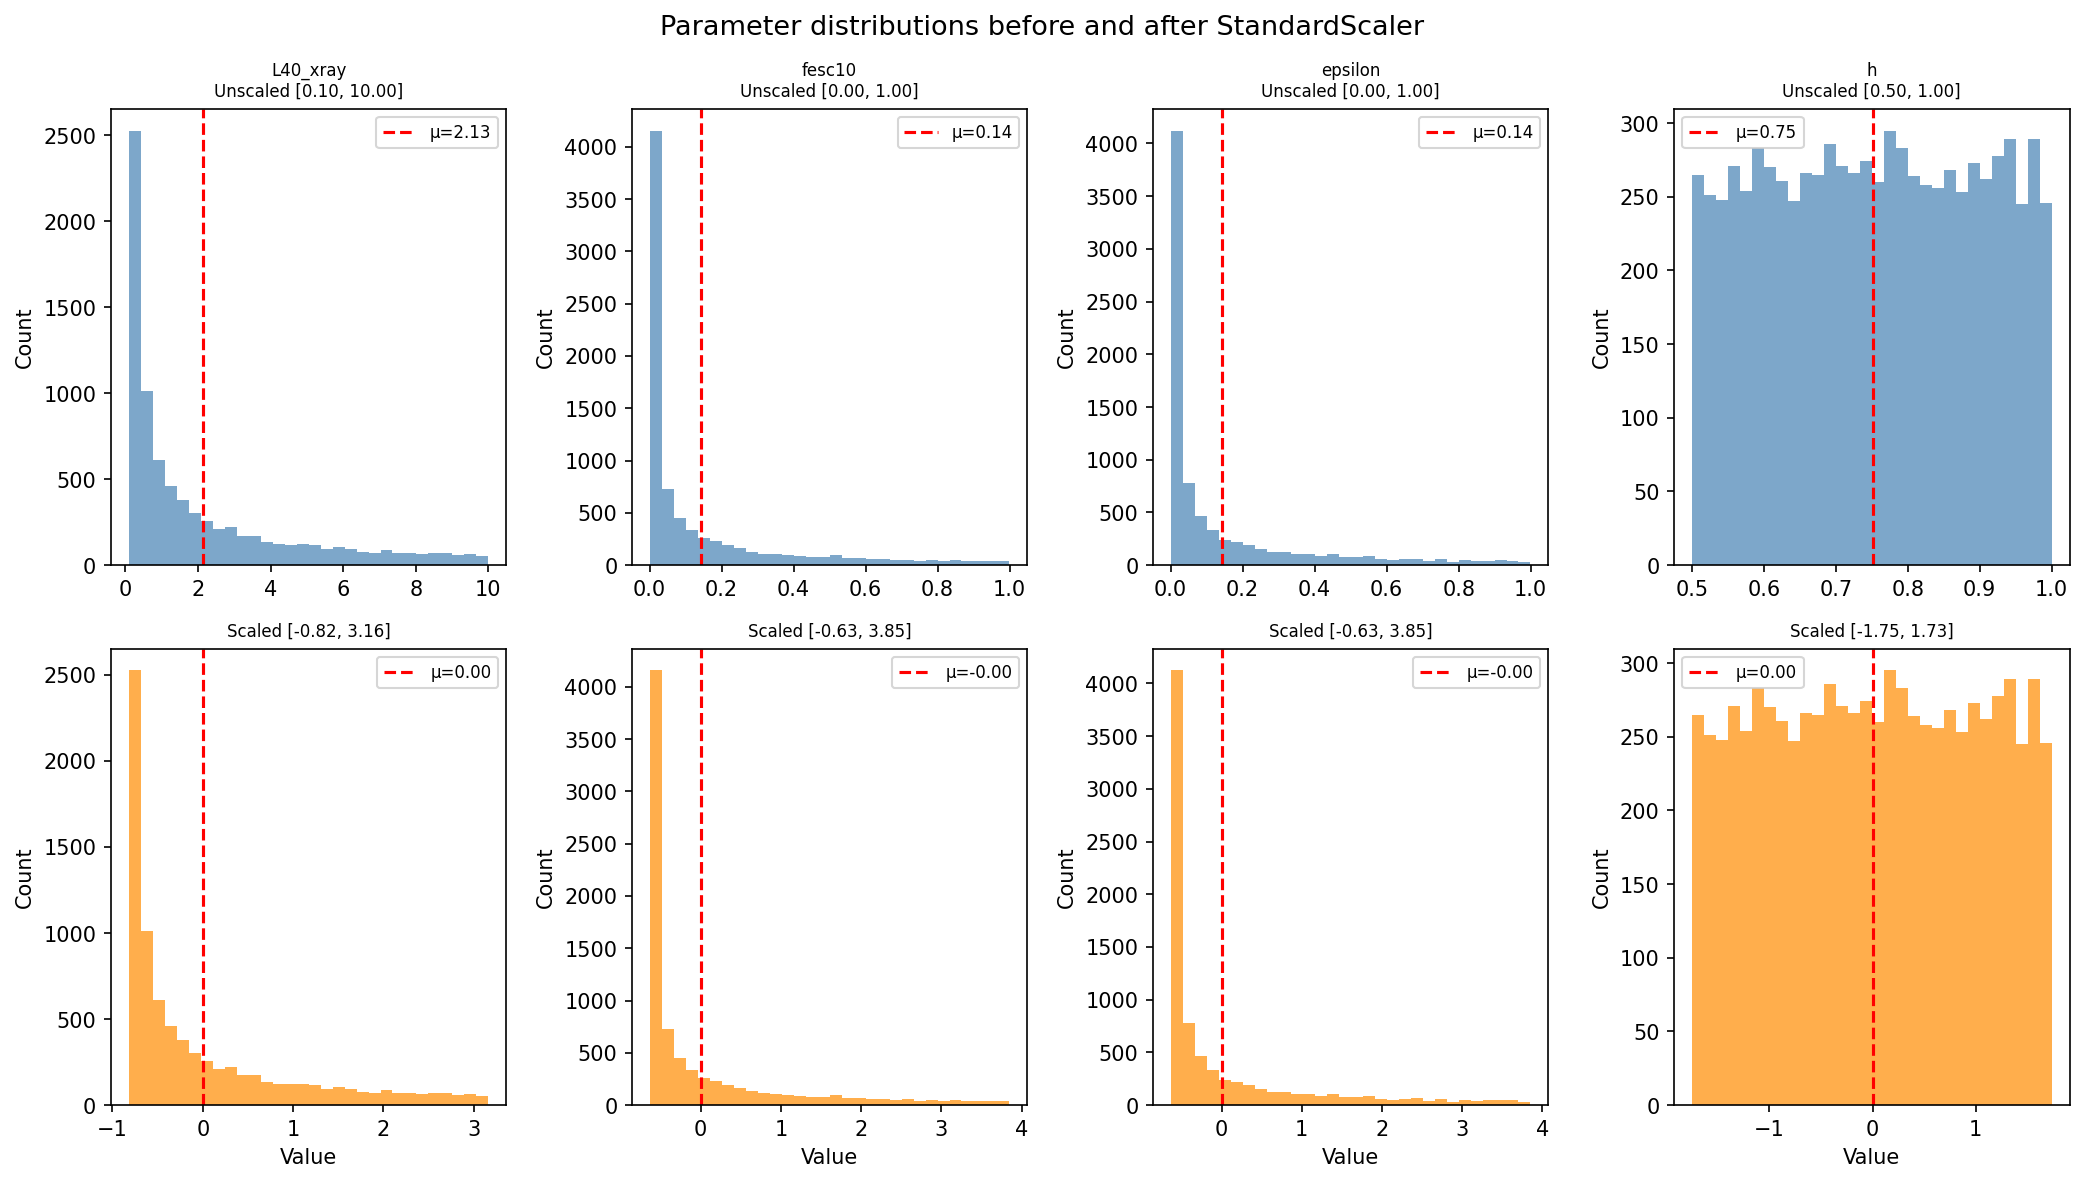

In [ ]:
from utils.emulator.plot import plot_pca_train_weights

unscaled_feature_domains =  plot_pca_train_weights(processed,n_comp=n_comp)

- We should normalise each one to to have zero mean and unit variance for best NN performance.

- This looks good. Now we train the NN. 
- We will train a fully connected model. 
- To determine the depth, width, and LR we will use for the model, I will run an optuna optimisation.
- All of this has been shifted to the optuna_optimize_emulator script. It searches through:
    - Number of layers of a dense model between 3 and 10.
    - Hidden dims [32, 64, 128, 256, 512]
    - Learning rate
    - Weight decay regularisation.
- It then retrains the best model and saves it. For more details on the model, please see my report.
- I will just reimport the model here. 

In [159]:
from utils.emulator.emulator import Emulator
from utils.emulator.evaluate_emulator import evaluate_emulator

# Load checkpoint
checkpoint = torch.load("optuna_outputs/local_run/best_model_run50_reconstruction_log_1.65pct.pt", 
                         map_location="cpu")

# Form model
emulator_model = Emulator(
    input_dim=checkpoint["input_dim"],
    output_dim=checkpoint["output_dim"],
    hidden_dim=checkpoint["best_params"]["hidden_dim"],
    num_layers=checkpoint["best_params"]["num_layers"],
)

emulator_model.load_state_dict(checkpoint["model_state_dict"])
emulator_model.eval()

# Load saved model data
with open("optuna_outputs/local_run/preprocessing_run50_reconstruction_log_1.65pct.pkl", "rb") as f:
    preproc = pickle.load(f)

emulator_evaluation_data = evaluate_emulator(emulator_model, processed, device="cpu")
print(f"The model mean frac error is {emulator_evaluation_data['mean_percentage_error']:.2f}%")
print(f"The model 95th percentile frac error is {emulator_evaluation_data['p95_percentage_error']:.2f}%")
print(f"The best parameters are {checkpoint['best_params']}")

The model mean frac error is 1.65%
The model 95th percentile frac error is 5.63%
The best parameters are {'num_layers': 3, 'hidden_dim': 128, 'lr': 0.004860645882927601, 'weight_decay': 1.0535946145298462e-05}


- Now examine emulator_model's performance on the test set.

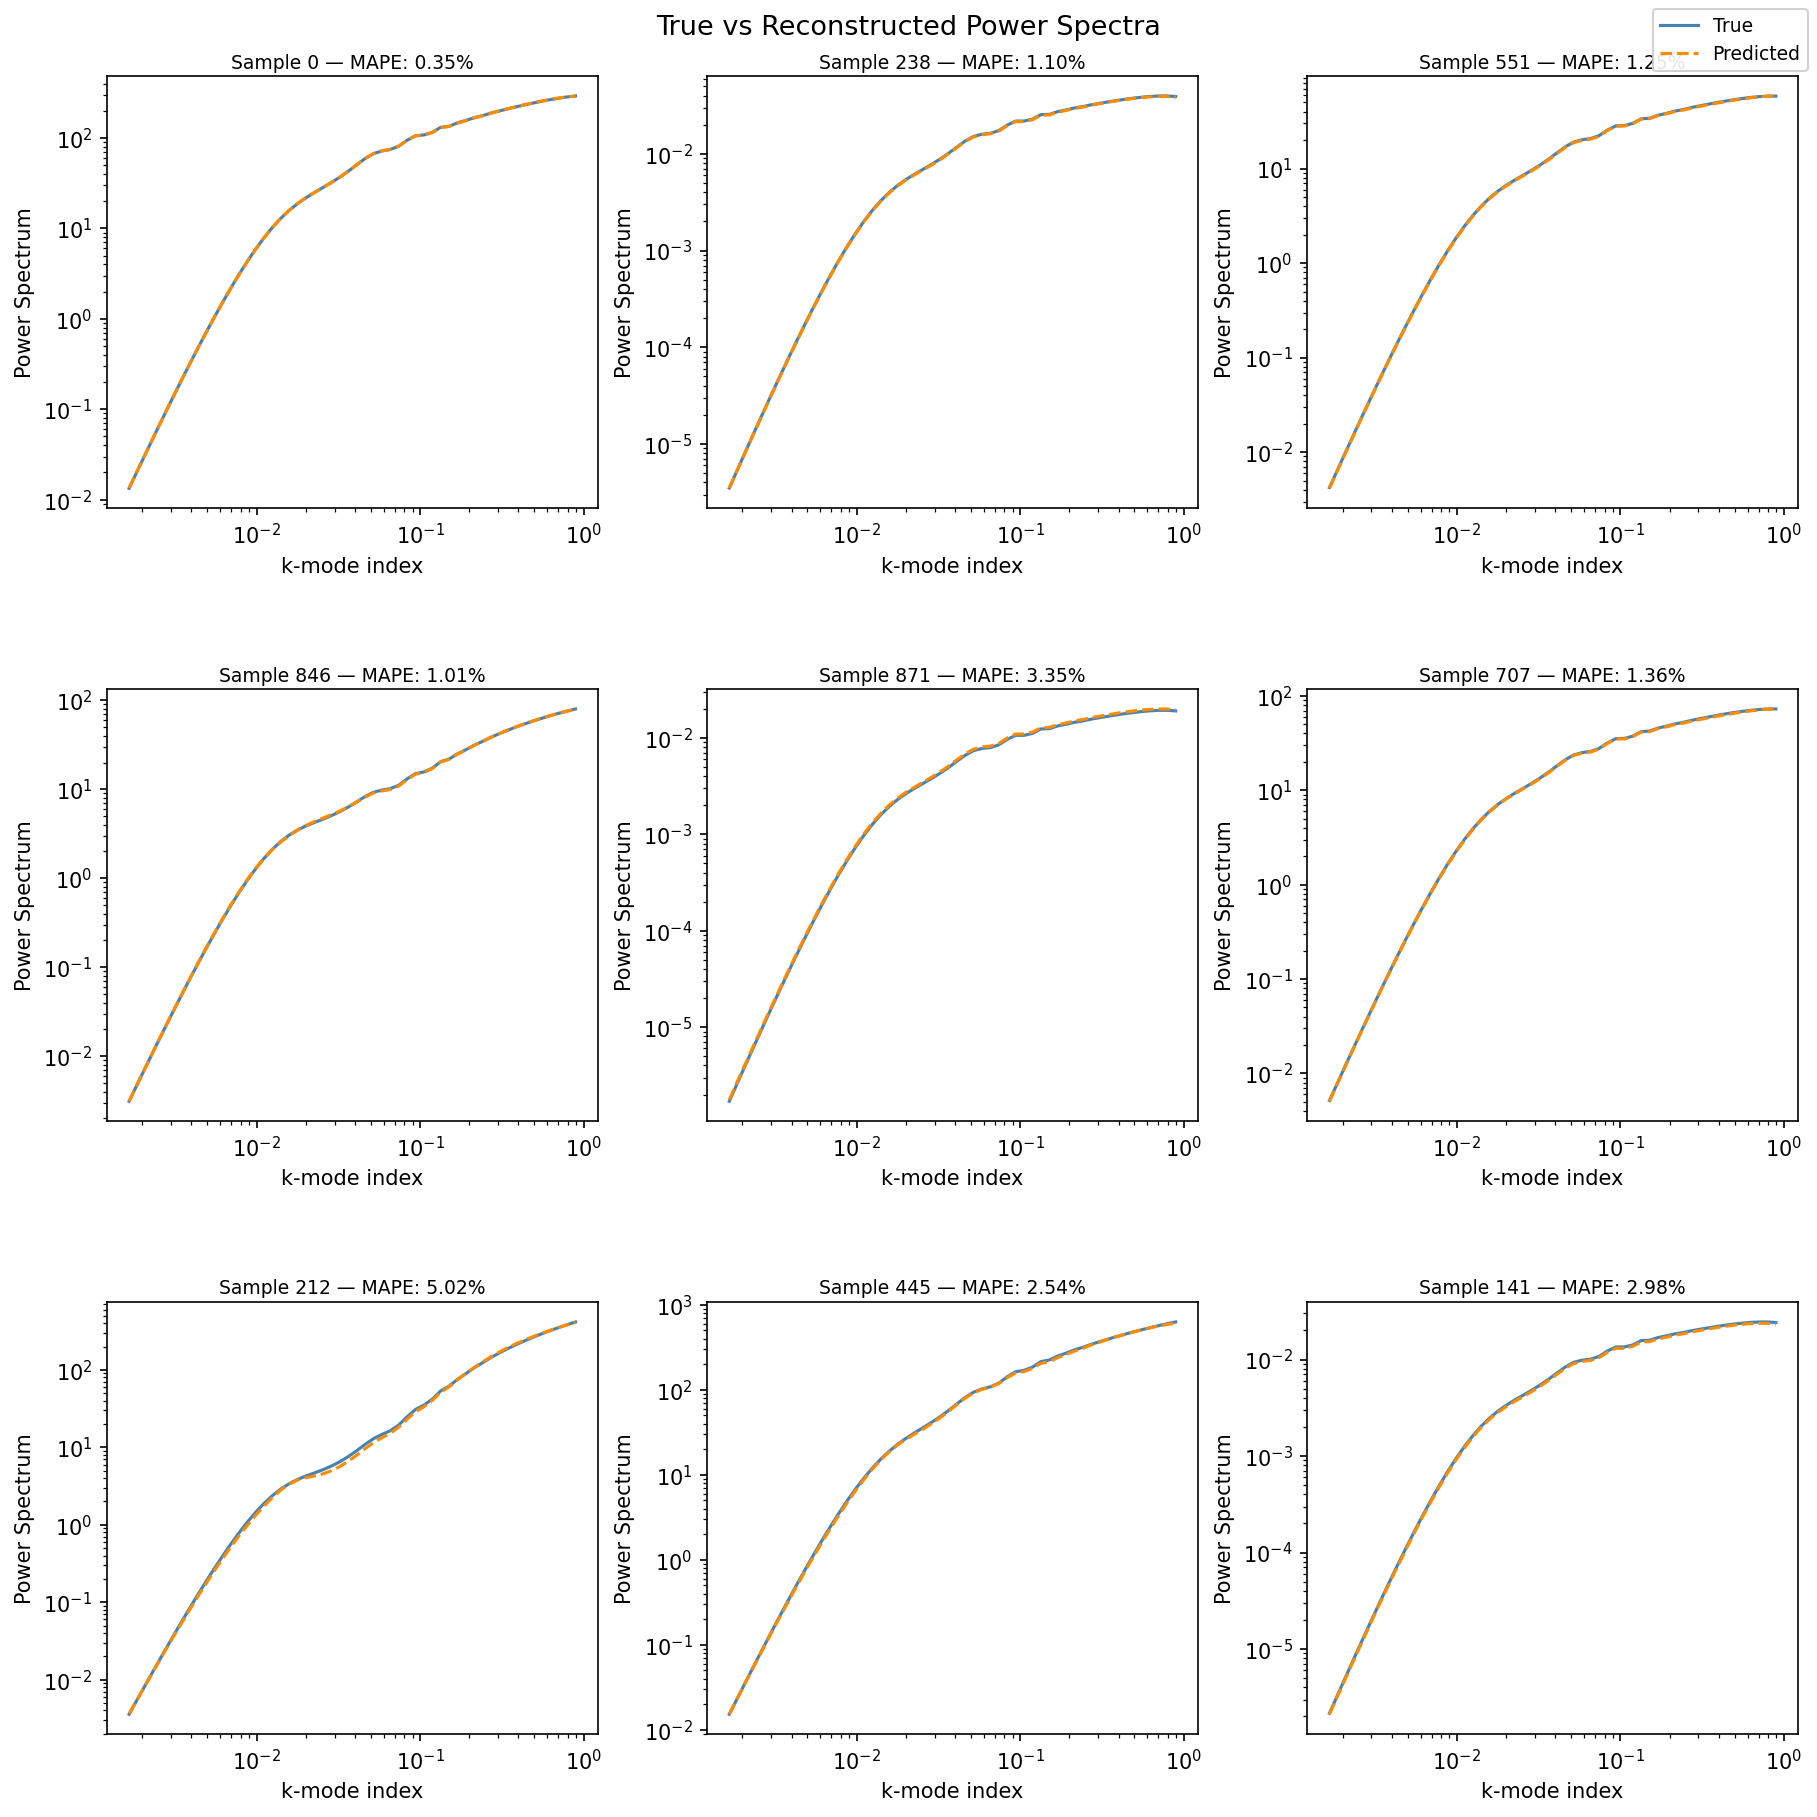

In [ ]:
from utils.emulator.plot import plot_emulator_test_reconstructions

plot_emulator_test_reconstructions(emulator_evaluation_data, processed)

This looks great!

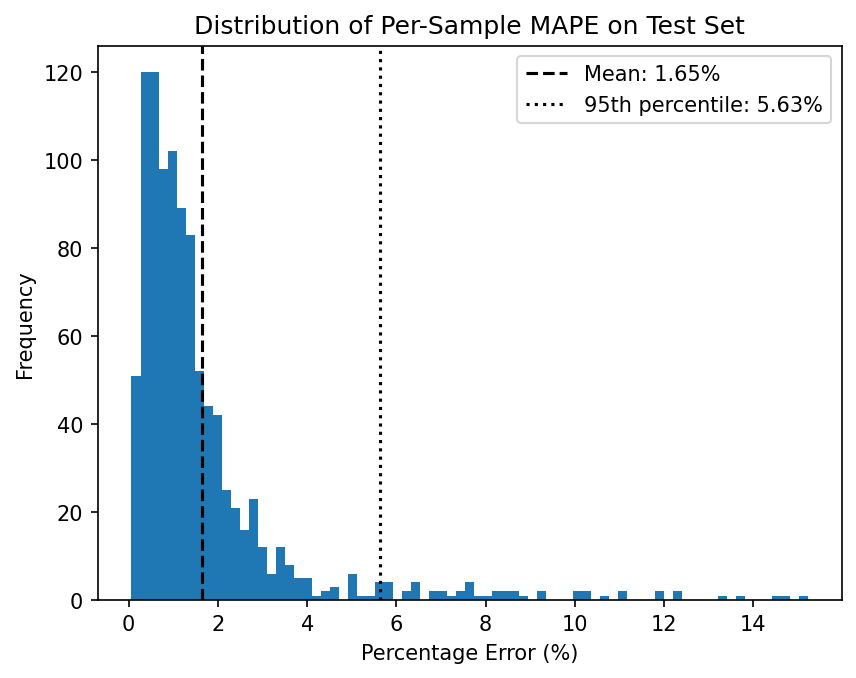

In [165]:
from utils.emulator.plot import plot_mape_distribution

plot_mape_distribution(emulator_evaluation_data)

## c)

In [13]:
observation_path= Path("observations/observations.npz")
with np.load(observation_path, allow_pickle=True) as d:
    observation = dict(d)


In [14]:
for k, (lo, hi) in unscaled_feature_domains.items():
    print(f"{k}: [{lo:.3g}, {hi:.3g}]  →  {np.log10(hi/lo):.1f} decades")

L40_xray: [0.1, 10]  →  2.0 decades
fesc10: [0.001, 1]  →  3.0 decades
epsilon: [0.001, 1]  →  3.0 decades
h: [0.5, 1]  →  0.3 decades


- This is pretty big. This motivates sampling in log space.

In [15]:
from helpers.sampling import generate_chain
import json

run = False # Prevent this from running when run all is done
if run == True:
    ln_sampled_posterior = generate_chain(steps = 25000, discard = 0, unscaled_feature_domains=unscaled_feature_domains, model=model, 
                                   p_obs=observation['power'], processed=processed, tf=1)
    np.save("thinned_samples.npy",   ln_sampled_posterior["thinned_samples"]) #unflattened
    np.save("unthinned_samples.npy", ln_sampled_posterior["unthinned_samples"])
    with open("diagnostics.json", "w") as f:
        json.dump({
            "mean_frac": float(ln_sampled_posterior["mean_frac"]),
            "taus":      ln_sampled_posterior["taus"].tolist(),
            "mean_tau":  float(ln_sampled_posterior["mean_tau"]),
            "tau":       int(ln_sampled_posterior["tau"]),
        }, f, indent=2)


In [16]:
thinned_chain   = np.exp(np.load("saved/thinned_samples.npy"))     # shape (steps, n_walkers, 5)
unthinned_chain   = np.exp(np.load("saved/unthinned_samples.npy"))     # shape (steps, n_walkers, 5)
with open("diagnostics.json") as f:
    diag = json.load(f)

(25000, 32, 5)
(768000, 5)


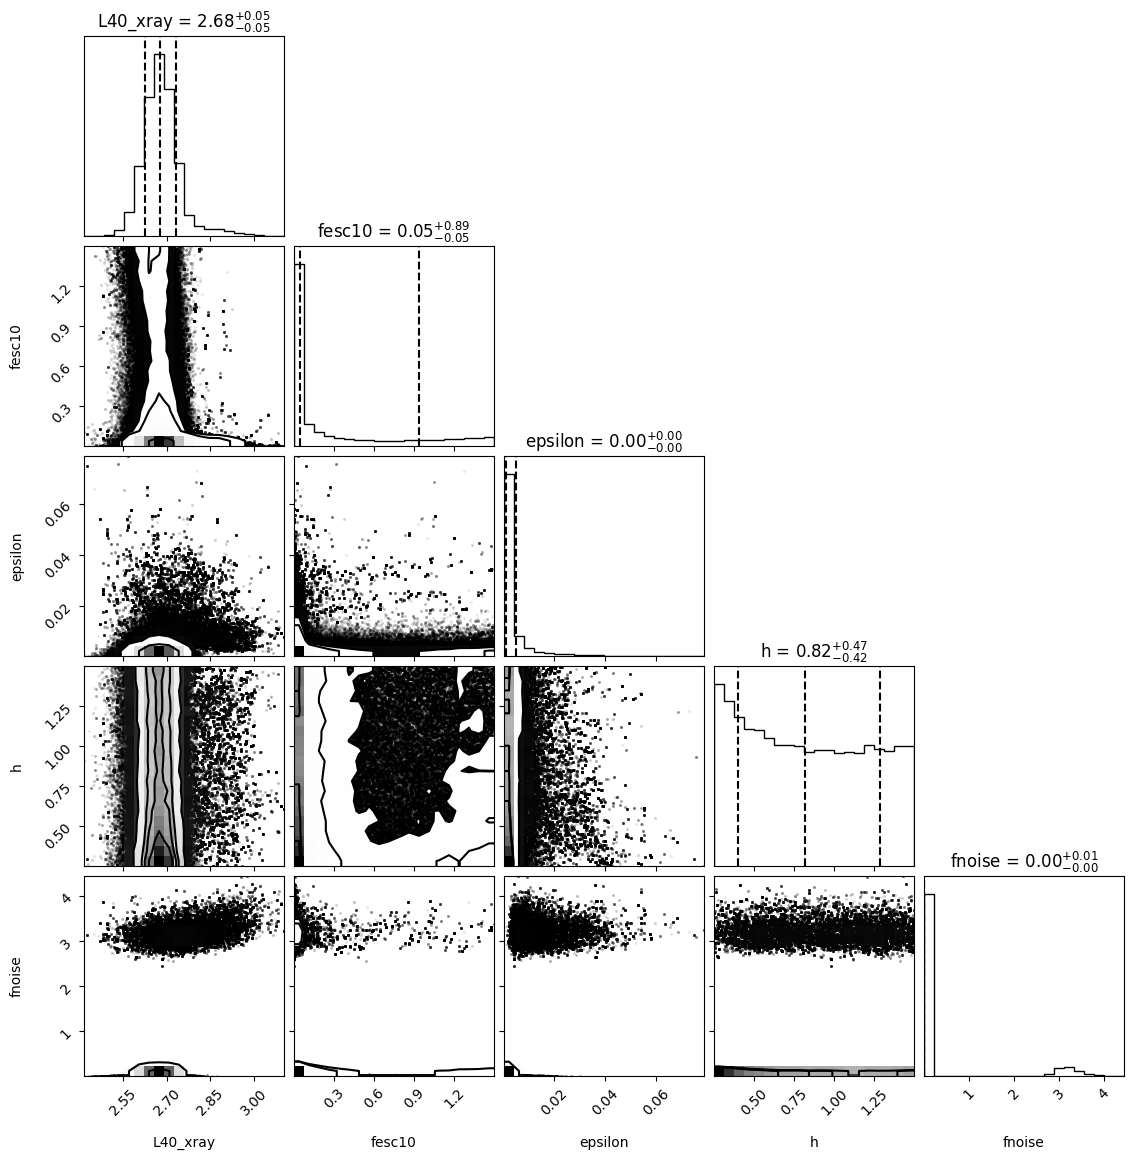

In [17]:
import corner

print(unthinned_chain.shape)
flat = unthinned_chain[1000:, :, :5].reshape(-1, 5)
print(flat.shape)  # should be (large_number, 5)

discard = 1000  # whatever you used in generate_chain
labels  = ["L40_xray", "fesc10", "epsilon", "h", "fnoise"]

# thinned chain — use this for corner (decorrelated samples)
# flat = thinned_chain[discard:, :, :5].reshape(-1, 5) 
corner.corner(
      flat,
      labels=labels,
      show_titles=True,
      quantiles=[0.16, 0.5, 0.84],
  )
plt.show()

In [18]:
from run_dynesty import build_sampler, plot_corner
if run == True:
    results = build_sampler(
        model=model,
        processed=processed,
        p_obs=observation['power'],
        domains=unscaled_feature_domains,
        nlive=1500,
    )

In [19]:
if run == True:
    fig, samples = plot_corner(results)

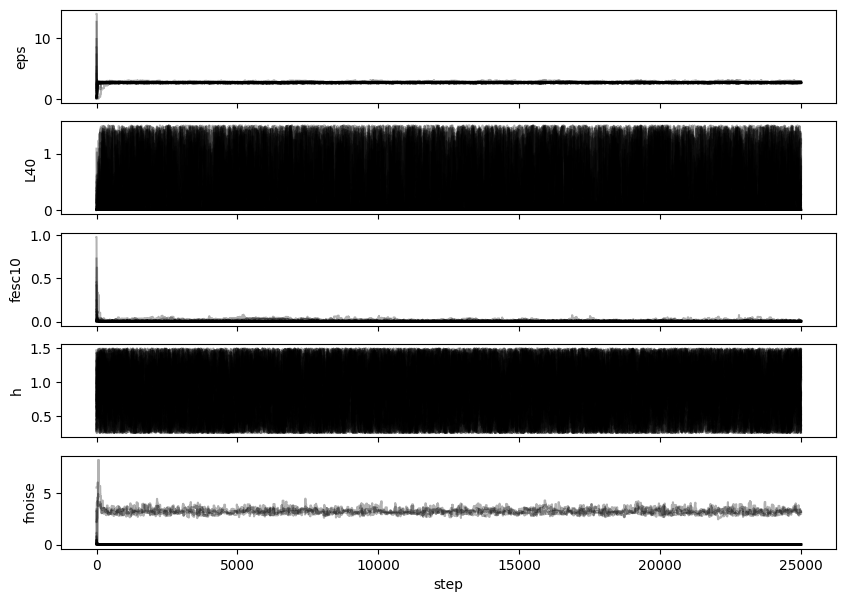

In [20]:
from helpers.convergence_tests import trace_plot
trace_plot(unthinned_chain)

# 2)
## a) 
- See report


## b) Draw noisy samples from likelihood


In [71]:
theta4_train, theta4_val, theta4_test = raw_data['raw_params_train'], raw_data['raw_params_val'], raw_data['raw_params_test']
pmodel_train, pmodel_val, pmodel_test = raw_data['power_train'], raw_data['power_val'], raw_data['power_test']
n_fnoise = 5 # draw one fnoise for each simulation

def noisify(pmodel, theta4, n_fnoise): # pmodel is just the mean
    n_models = pmodel.shape[0] # shape (n_models ,54)

    # draw fnoise
    fnoise = 10**np.random.uniform(-3,0, size=(n_models, n_fnoise)) # size (n_models, n_fnoise)
    
    # reshape to targe (n_models, n_fnoise, 54)
    pmodel_r = pmodel[:, np.newaxis, :] # (n_models, 1, 54)
    fnoise_r = fnoise[:, :, np.newaxis] # (n_models, n_fnoise, 1)

    # variances
    var = 0.02 * (pmodel_r**2) * ((1-fnoise_r)**2) # (n_models, n_fnoise, 54)

    # draw the gaussian
    pnoisy =  np.random.normal(pmodel_r, np.sqrt(var)) #yields (n_models, n_fnoise, 54)

    
    theta_r = np.repeat(theta4, n_fnoise, axis=0)  # (n_models * n_fnoise, 4)
    fnoise_flat = fnoise.reshape(-1, 1)              # (n_models * n_fnoise, 1)
    pnoisy_flat = pnoisy.reshape(-1, 54)               # (n_models * n_fnoise, 54)

    theta_noisy = np.concatenate([theta_r, fnoise_flat], axis=1) # (n_models * n_fnoise, 5)

    return pnoisy_flat, theta_noisy

pnoisy_train, theta5_train = noisify(pmodel_train, theta4_train, n_fnoise =n_fnoise)
pnoisy_test, theta5_test = noisify(pmodel_test, theta4_test, n_fnoise =n_fnoise)
pnoisy_val, theta5_val = noisify(pmodel_val, theta4_val, n_fnoise =n_fnoise)

pnoisy_train.shape
    

(39985, 54)

[0.00166234 0.00187171 0.00210745 0.00237288 0.00267174 0.00300824
 0.00338713 0.00381373 0.00429407 0.0048349  0.00544385 0.00612949
 0.0069015  0.00777073 0.00874945 0.00985143 0.0110922  0.01248925
 0.01406226 0.01583338 0.01782758 0.02007294 0.0226011  0.02544768
 0.02865278 0.03226156 0.03632487 0.04089994 0.04605123 0.05185133
 0.05838194 0.06573507 0.07401432 0.08333633 0.09383244 0.10565052
 0.11895707 0.13393956 0.15080909 0.1698033  0.19118982 0.21526993
 0.24238291 0.27291074 0.30728351 0.34598548 0.38956192 0.43862676
 0.49387125 0.55607372 0.62611051 0.70496834 0.79375823 0.89373108]


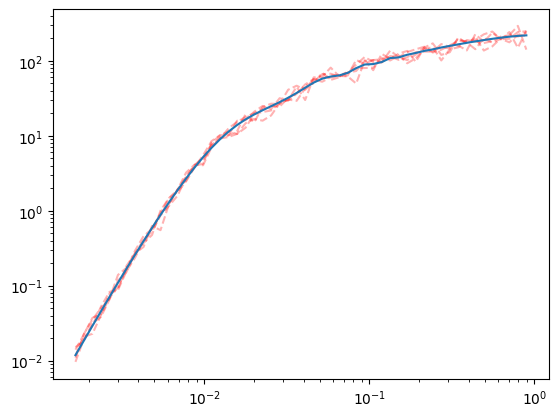

In [72]:
idx = 1439



k_train = raw_data['k_train']
print(k_train[idx])

pnoisy_train_idx = pnoisy_train[idx: idx+n_fnoise] #(n_fnoise, 54)
# lower, upper = np.percentile( pnoisy_train_idx,[16, 84], axis=0)

start = idx * n_fnoise



for i in range(0, n_fnoise):
    plt.loglog(k_train[idx], pnoisy_train[start + i], color='red', linestyle='--', alpha=0.3)
    # plt.loglog(k_train[j], pnoisy_train[j], color = 'red', linestyle = '--', label = f"{i}th noisy version")
    # plt.fill_between(k_train[j], lower, upper, alpha=0.2, color='blue', label=r'90% uncertainty')
plt.loglog(k_train[idx], pmodel_train[idx], label = "Ideal")

## c)


In [73]:
def make_nre_dataset(pnoisy, theta5, plot = False):
    # joint pairs 
    pnoisy_j = pnoisy #(n_models, 54)
    theta5_j = theta5 #(n_models, 5)

    # disjoint pais
    shuffled_idx = np.random.permutation(len(pnoisy))
    pnoisy_d = pnoisy #(n_models, 54)
    theta5_d = theta5[shuffled_idx] # (n_models, 5)

    # concat
    pnoisy_nre = np.concatenate([pnoisy_j, pnoisy_d]) #(2*n_models, 54)
    theta5_nre = np.concatenate([theta5_j, theta5_d]) #(2*n_models, 5)
    labels_nre = np.concatenate([np.ones(len(pnoisy)), np.zeros(len(pnoisy))]) #(2*n_models)

    if plot == True:
        fig, ax = plt.subplots(1,5,figsize=(25,5))
        idx_k = np.argmin(np.abs(k_train - 0.1))
        pnoisy_slice = pnoisy_nre[:, idx_k] #(2*n_models,1)
        
        # each panel is power vs one of our params
        labels = ["L40_xray", "fesc10", "epsilon", "h", "fnoise"]
        for i, label in enumerate(labels):
            theta5_slice = theta5_nre[:,i]
            ax[i].scatter(theta5_slice[:len(pnoisy)], pnoisy_slice[:len(pnoisy)], color = 'blue', label = "Joint Distribution", s=1, alpha=0.3)
            ax[i].scatter(theta5_slice[len(pnoisy):], pnoisy_slice[len(pnoisy):], color = 'red', label = "Disjoint Distribution", s=1, alpha=0.3)
            ax[i].legend()
            ax[i].set_title(f"{label} vs $P_{{noisy}}$ at k = 0.1")
            ax[i].set_xlabel(label)
            ax[i].set_ylabel("$P_{{noisy}}$")
        fig.tight_layout()
        fig.show()

            

        

    # shuffle final 
    shuffled_idx = np.random.permutation(2*len(pnoisy))
    pnoisy_nre =pnoisy_nre[shuffled_idx] 
    theta5_nre = theta5_nre[shuffled_idx]
    labels_nre = labels_nre[shuffled_idx]

    nre_dataset={
        "pnoisy":pnoisy_nre,
        "theta5":theta5_nre,
        "labels":labels_nre
    }
    return nre_dataset


C:\Users\Joey\AppData\Local\Temp\ipykernel_15420\3246851276.py:32: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


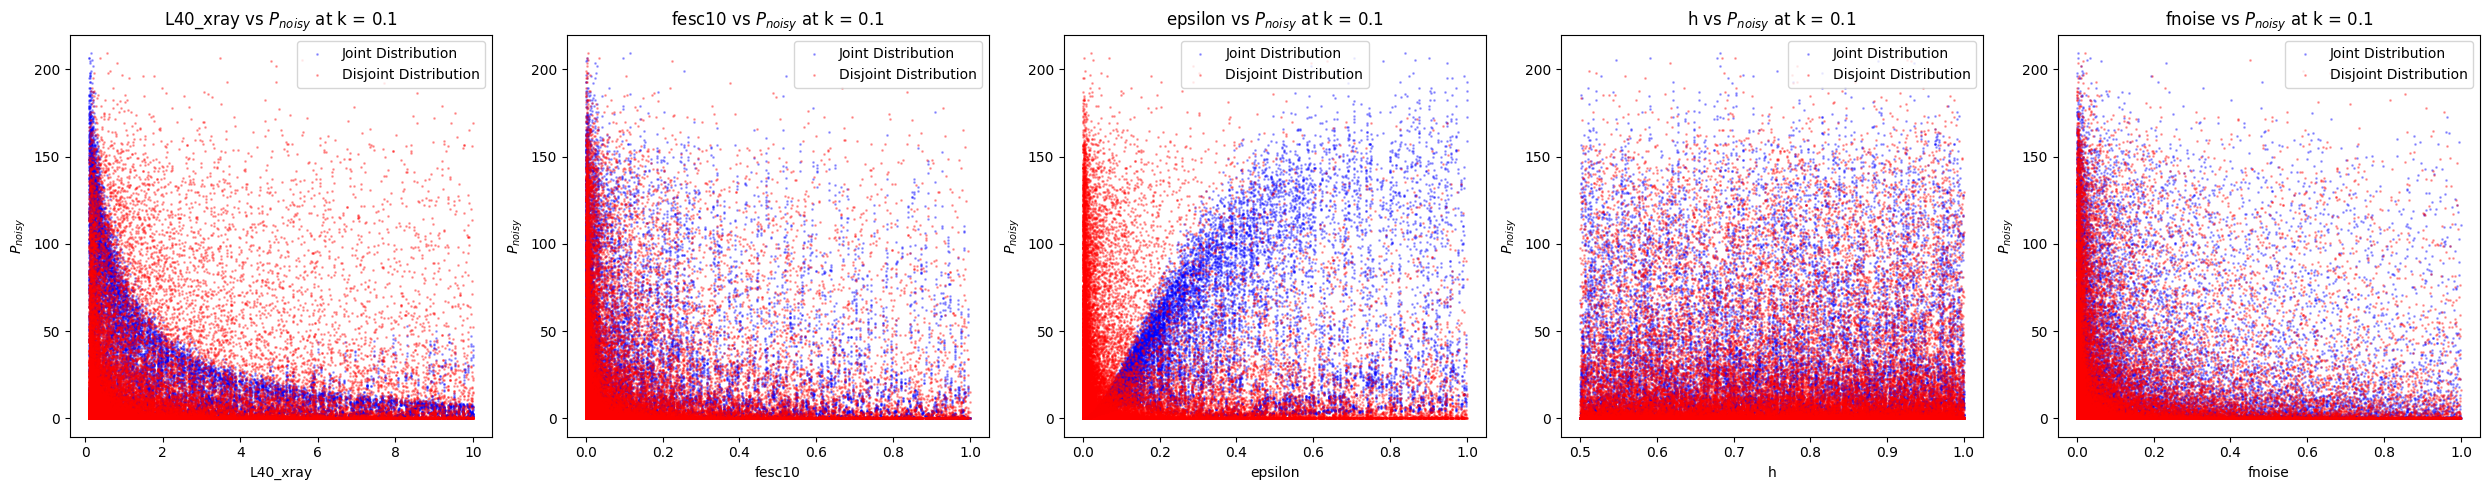

In [74]:
nre_train = make_nre_dataset(pnoisy_train,theta5_train, plot=True)
nre_val = make_nre_dataset(pnoisy_val,theta5_val)
nre_test = make_nre_dataset(pnoisy_test,theta5_test)

## d) Build and train NRE

In [76]:
class NRE(nn.Module):
    def __init__(self):
        super().__init__()
        # self.layers = nn.Sequential(
        #     nn.Linear(59, 128), # 54 k plus theta5
        #     nn.BatchNorm1d(128),
        #     nn.Sigmoid(),
        #     nn.Linear(128, 100),
        #     nn.BatchNorm1d(100),
        #     nn.Sigmoid(),
        #     nn.Linear(100, 100),
        #     nn.BatchNorm1d(100),
        #     nn.Sigmoid(),
        #     nn.Linear(100, 1),
        # )
        self.layers = nn.Sequential(
            nn.Linear(59, 128),
            nn.ReLU(),
            nn.Linear(128, 100),
            nn.ReLU(),
            nn.Linear(100, 100),
            nn.ReLU(),
            nn.Linear(100, 1),
        )
    
    def forward(self, x):
        # x is shape (n_samps, 59)
        return self.layers(x)


In [77]:
from torch.nn import BCEWithLogitsLoss
import copy
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import optuna
from torch import reshape
from helpers.set_seed import set_seed

def train_nre(model, nre_trainset, nre_valset,epochs = 1000, batch_size=1024, device='cpu', verbose=True, plot = True, patience = 250):
    pnoisy = np.log(nre_trainset['pnoisy'])
    theta5 = nre_trainset['theta5']
    x_train = torch.tensor(np.concatenate([pnoisy, theta5], axis = 1), dtype=torch.float32) # (n_samples, 59)
    y_train = torch.tensor(nre_trainset['labels'], dtype=torch.float32).reshape(-1, 1) #the 1 and 0 indicating if they are join or disjoint (n_samples,)
    x_scaler = StandardScaler()  # used to scale the inputs (powervk and theta5)
    
    x_scaler.fit(x_train)
    x_train = torch.tensor(x_scaler.transform(x_train), dtype=torch.float32)


    pnoisy = np.log(nre_valset['pnoisy'])
    theta5 = nre_valset['theta5']
    x_val = torch.tensor(np.concatenate([pnoisy, theta5], axis = 1), dtype=torch.float32 )# (n_samples_val, 59)
    y_val = torch.tensor(nre_valset['labels'], dtype=torch.float32).reshape(-1, 1)

    x_val = torch.tensor(x_scaler.transform(x_val), dtype=torch.float32)

    set_seed(1701)
    model = model.to(device)

    # use the BCEWithLogitsLoss from pytorch
    BCE_loss = BCEWithLogitsLoss()
    optimiser = optim.Adam(model.parameters(), lr=1e-5)

    best_valid_loss        = float("inf")
    best_train_loss        = None
    best_epoch             = -1
    best_state_dict        = None
    epochs_since_improvement = 0

    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        model.train()
        total_train_loss = 0.0
        num_batches = 0

        # shuffling
        perm = torch.randperm(len(x_train), device=device)
        x_shuffled = x_train[perm]
        y_shuffled = y_train[perm]

        # loop through batches each epoch
        for start in range(0, len(x_shuffled), batch_size): 
            x_batch = x_shuffled[start : start + batch_size]
            y_batch = y_shuffled[start : start + batch_size]

            optimiser.zero_grad()
            loss = BCE_loss(model(x_batch), y_batch)
            loss.backward()
            optimiser.step()

            total_train_loss += float(loss.item())
            num_batches += 1
        avg_train_loss = total_train_loss / max(num_batches, 1) # across this epoch
        train_losses.append(avg_train_loss)
        # Validation
        model.eval()
        with torch.no_grad():
            valid_loss = float(BCE_loss(model(x_val), y_val).item())
            val_losses.append(valid_loss)

        # Bookkeeping
        if valid_loss < best_valid_loss:
                best_valid_loss          = valid_loss
                best_train_loss          = avg_train_loss
                best_epoch               = epoch
                best_state_dict          = copy.deepcopy(model.state_dict())
                epochs_since_improvement = 0
        else:
            epochs_since_improvement += 1

        if verbose and (epoch % 100 == 0 or epoch == epochs - 1):
                lr_now = optimiser.param_groups[0]["lr"]
                print(f"Epoch {epoch + 1}/{epochs} | ",
                    f"train={avg_train_loss:.6f} | val={valid_loss:.6f} ",
                    flush=True,
                )
        
        if epochs_since_improvement >= patience:
                if verbose:
                    print(
                        f"Early stopping at epoch {epoch + 1}. "
                        f"Best epoch: {best_epoch + 1}.",
                        flush=True,
                    )
                break

    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)

    if plot == True:
        plt.plot(train_losses, label='Train Loss')
        plt.plot(val_losses, label='Validation Loss')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.show()

    return best_valid_loss, best_train_loss, best_epoch, model, x_scaler


            


Epoch 1/2000 |  train=0.692239 | val=0.691578 
Epoch 101/2000 |  train=0.422403 | val=0.423130 
Epoch 201/2000 |  train=0.351282 | val=0.358196 
Epoch 301/2000 |  train=0.308731 | val=0.318035 
Epoch 401/2000 |  train=0.278146 | val=0.289309 
Epoch 501/2000 |  train=0.253553 | val=0.265325 
Epoch 601/2000 |  train=0.231571 | val=0.244315 
Epoch 701/2000 |  train=0.215049 | val=0.227832 
Epoch 801/2000 |  train=0.197971 | val=0.211169 
Epoch 901/2000 |  train=0.182533 | val=0.194324 
Epoch 1001/2000 |  train=0.170938 | val=0.182468 
Epoch 1101/2000 |  train=0.159899 | val=0.173813 
Epoch 1201/2000 |  train=0.150202 | val=0.163147 
Epoch 1301/2000 |  train=0.144103 | val=0.154257 
Epoch 1401/2000 |  train=0.135435 | val=0.148319 
Epoch 1501/2000 |  train=0.129281 | val=0.141298 
Epoch 1601/2000 |  train=0.124004 | val=0.137639 
Epoch 1701/2000 |  train=0.118900 | val=0.132677 
Epoch 1801/2000 |  train=0.115360 | val=0.131536 
Epoch 1901/2000 |  train=0.110600 | val=0.126026 
Epoch 2000/2

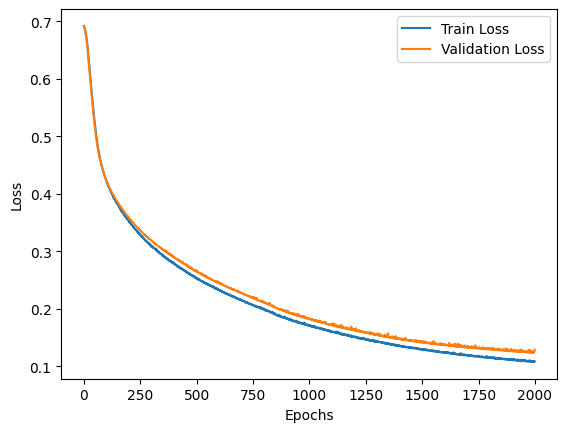

In [85]:
nre_model = NRE()
best_valid_loss, best_train_loss, best_epoch, model, x_scaler = train_nre(nre_model, nre_train, nre_val, epochs=2000)


In [86]:
checkpoint = {
    "model_state_dict": nre_model.state_dict(),
}
torch.save(checkpoint, "saved/nre_checkpoint.pt")

In [87]:
checkpoint = torch.load("saved/nre_checkpoint.pt")
model = NRE()
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

NRE(
  (layers): Sequential(
    (0): Linear(in_features=59, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=100, bias=True)
    (3): ReLU()
    (4): Linear(in_features=100, out_features=100, bias=True)
    (5): ReLU()
    (6): Linear(in_features=100, out_features=1, bias=True)
  )
)

## e) NRE Posterior Sampling

In [88]:
from scipy.stats import loguniform

def _build_priors(unscaled_feature_domains: dict) -> dict:
    """
    Construct loguniform prior objects once from feature domains.

    Call this once before sampling and pass the result to ln_uniform_prior
    and ln_post_vec so that prior objects are not re-created on every
    posterior evaluation.

    Parameters
    ----------
    unscaled_feature_domains : dict
        Dictionary mapping 'epsilon', 'L40_xray', 'fesc10', 'h' to
        [min, max] physical bounds.

    Returns
    -------
    dict
        loguniform objects keyed by 'epsilon', 'L40_xray', 'fesc10',
        'h', and 'fnoise'.
    """
    def make(key):
        lo, hi = unscaled_feature_domains[key]
        return loguniform(a=0.5 * lo, b=1.5 * hi)

    return {
        'epsilon':  make('epsilon'),
        'L40_xray': make('L40_xray'),
        'fesc10':   make('fesc10'),
        'h':        make('h'),
        'fnoise':   loguniform(a=1e-3, b=1e1),
    }


def ln_uniform_prior(L40, fesc10, eps, h, fnoise, priors):
    """
    Compute the joint log-prior probability using pre-built prior objects.

    Parameters
    ----------
    L40, fesc10, eps, h, fnoise : float
        Parameter values.
    priors : dict
        Pre-built loguniform objects keyed by 'L40_xray', 'fesc10',
        'epsilon', 'h', 'fnoise'. Build once with _build_priors().

    Returns
    -------
    float
        Sum of log-prior probabilities. -inf if any value is outside
        its prior support.
    """
    return (
        priors['h'].logpdf(h)
        + priors['epsilon'].logpdf(eps)
        + priors['L40_xray'].logpdf(L40)
        + priors['fesc10'].logpdf(fesc10)
        + priors['fnoise'].logpdf(fnoise)
    )


In [96]:
def nre_ln_post(thetas, priors, scaler, p_obs): # vectorised version
    n = len(thetas) # thetas is shape (n, 5)
    results = np.full(n, -np.inf)
    log_priors = np.zeros(n)
    valid = np.ones(n, dtype=bool)

    for i, (L40, fesc10, eps, h, fnoise) in enumerate(thetas):
        lnPi = ln_uniform_prior(L40=L40, fesc10=fesc10, eps=eps,
                                h=h, fnoise=fnoise, priors=priors)
        if not np.isfinite(lnPi):
            valid[i] = False
        else:
            log_priors[i] = lnPi

    if not np.any(valid):
        return results

    valid_thetas = thetas[valid]                                          # (m, 5)
    log_p_obs_tiled = np.tile(np.log(p_obs), (len(valid_thetas), 1))    # (m, 54)
    x_obs_raw = np.concatenate([log_p_obs_tiled, valid_thetas], axis=1) # (m, 59)
    x_obs = torch.tensor(scaler.transform(x_obs_raw), dtype=torch.float32)

    with torch.no_grad():
        lnr = model(x_obs).squeeze(1).cpu().numpy()                      # (m,)

    results[np.where(valid)[0]] = lnr + log_priors[valid]
    return results

In [109]:
import emcee as mc
def nre_generate_chain(n_walkers: int = 32,
        steps: int = 10000,
        discard: int = 0,
        tf: int = 2,
        unscaled_feature_domains: dict = None,
        model=None,
        p_obs: np.ndarray = None,
        processed: dict = None,
) -> tuple:
    # Build prior objects once — shared across all n_walkers * steps evaluations
    priors = _build_priors(unscaled_feature_domains)

    rng = np.random.default_rng(seed=1701)
    initial_pos = np.column_stack([
        priors[key].rvs(size=n_walkers, random_state=rng)
        for key in ('L40_xray', 'fesc10', 'epsilon', 'h', 'fnoise')
    ])

    # Set eval mode once before sampling — not per-call inside ln_post_vec
    model.eval()

    # vectorize=True: emcee passes all n_walkers//2 positions at once,
    # enabling the single batched forward pass in ln_post_vec
    sampler = mc.EnsembleSampler(
        n_walkers,
        ndim=5,
        log_prob_fn=nre_ln_post,
        args=[priors, x_scaler, p_obs],
        vectorize=True,
    )

    sampler.run_mcmc(initial_pos, steps, progress=True)

    mean_frac = sampler.acceptance_fraction.mean()
    taus = sampler.get_autocorr_time()
    if np.any(np.isnan(taus)):
        print("Warning: autocorrelation time could not be estimated (chain too short or walkers stuck)")
        print("Using tau=1 (no thinning) — consider running longer")
        tau = 1
    else:
        mean_tau = np.mean(taus)
        tau = int(max(taus))
        print(f"Mean autocorrelation time: {mean_tau:.2f} steps")

    
        print(f"Mean acceptance fraction: {mean_frac:.3f}")
    
    thinned_samples = sampler.get_chain(discard=discard, thin=tf * tau, flat=False)
    unthinned_samples = sampler.get_chain(discard=discard, flat=False)

    return {
        "sampler": sampler,
        "mean_frac": mean_frac,
        "thinned_samples": thinned_samples,
        "unthinned_samples": unthinned_samples,
    }

In [ ]:
# if run == True:
nre_sampled_posterior = nre_generate_chain(steps = 10000, discard = 0, unscaled_feature_domains=unscaled_feature_domains, model=model, 
                                   p_obs=observation['power'], processed=processed)


100%|██████████| 100000/100000 [21:16<00:00, 78.35it/s]


AutocorrError: The chain is shorter than 50 times the integrated autocorrelation time for 1 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 2000;
tau: [ 700.27866254 1801.02416357 1899.64884961 1215.76750183 2602.53465493]

In [120]:
# def nre_lnr(theta5, p_obs, model, scaler):
#     L40, fesc10, eps, h, fnoise = theta5
    
#     # Need to normalise inputs using our scaler
#     x_obs_raw = torch.tensor(np.concatenate([np.log(p_obs), theta5]), dtype=torch.float32).reshape(1,-1) # (n_samples, 59)
#     x_obs = scaler.transform(x_obs_raw)
#     x_obs = torch.tensor(x_obs, dtype=torch.float32)

#     with torch.no_grad():
#         lnr = model.forward(x_obs)                 # (m,)

#     return lnr 

def nre_lnr(theta5, p_obs, model, scaler):
    theta5 = np.atleast_2d(theta5)                                   # (1, 5) or (N, 5)
    
    p_obs_log = np.log(p_obs)                                        # (54,)
    p_obs_tiled = np.tile(p_obs_log, (theta5.shape[0], 1))          # (N, 54)
    
    x_raw = np.concatenate([p_obs_tiled, theta5], axis=1)           # (N, 59)
    x_scaled = scaler.transform(x_raw)                              # (N, 59)
    x_tensor = torch.tensor(x_scaled, dtype=torch.float32)          # (N, 59)

    with torch.no_grad():
        lnr = model(x_tensor).squeeze(-1)                           # (N,)

    return lnr.cpu().numpy().squeeze()                              # scalar or (N,)


In [121]:
def make_prior_transform(domains: dict):
    """
    Return a function mapping u ~ Uniform[0,1]^5 to physical parameters
    under log-uniform priors (matching helpers/sampling.py).

    Parameter order: [L40, fesc10, eps, h, fnoise]

    Prior support is widened to [0.5*lo, 1.5*hi] per domain key,
    matching _build_priors() in sampling.py.
    """
    bounds = [
        (0.5 * domains['L40_xray'][0], 1.5 * domains['L40_xray'][1]),
        (0.5 * domains['fesc10'][0],   1.5 * domains['fesc10'][1]),
        (0.5 * domains['epsilon'][0],  1.5 * domains['epsilon'][1]),
        (0.5 * domains['h'][0],        1.5 * domains['h'][1]),
        (1e-3, 1e1),   # fnoise
    ]
    log_lo = np.array([np.log(lo) for lo, _ in bounds])
    log_hi = np.array([np.log(hi) for _, hi in bounds])

    def prior_transform(u):
        return np.exp(log_lo + u * (log_hi - log_lo))

    return prior_transform



In [122]:
import dynesty
def build_sampler(
    model,
    processed: dict,
    p_obs: np.ndarray,
    domains: dict,
    nlive: int = 500,
    print_progress: bool = True,
    scaler = None,
):
    """
    Run dynesty DynamicNestedSampler and return the results object.

    Parameters
    ----------
    model : nn.Module
        Trained emulator in eval() mode.
    processed : dict
        Preprocessing artefacts (weight_scaler, pca, log_power).
    p_obs : np.ndarray of shape (54,)
        Observed power spectrum.
    domains : dict
        Feature domains with keys 'epsilon', 'L40_xray', 'fesc10', 'h'.
    nlive : int
        Number of live points. Higher = more accurate but slower.
        500 is a reasonable default; 1000 for publication quality.
    print_progress : bool
        Whether to print dynesty progress.

    Returns
    -------
    dynesty.results.Results
        Contains samples (physical space), weights, and log-evidence.
    """
    model.eval()

    prior_transform = make_prior_transform(domains)
    

    log_like = lambda theta: nre_lnr(theta, p_obs=p_obs, model=model, scaler=scaler)

    sampler = dynesty.DynamicNestedSampler(
        log_like,
        prior_transform,
        ndim=5,
        nlive=nlive,
        bound="multi",
        sample="rwalk",
    )
    sampler.run_nested(print_progress=print_progress)
    return sampler.results

0it [00:00, ?it/s]c:\Users\Joey\Desktop\Cambridge\Work\A1\A1CW\Machine-Learning-Enhanced-Inference-of-the-21-cm-Power-Spectrum-at-Cosmic-Dawn\VenvA1Cw\lib\site-packages\dynesty\sampler.py:199: RuntimeWarning: overflow encountered in cast
  cur_live_logl[not_finite] = _LOWL_VAL
27493it [02:37, 174.51it/s, batch: 0 | bound: 17 | nc: 1 | ncall: 569044 | eff(%):  4.831 | loglstar:   -inf < 14.623 <    inf | logz:  1.907 +/-  0.074 | dlogz:  0.000 >  0.010] 


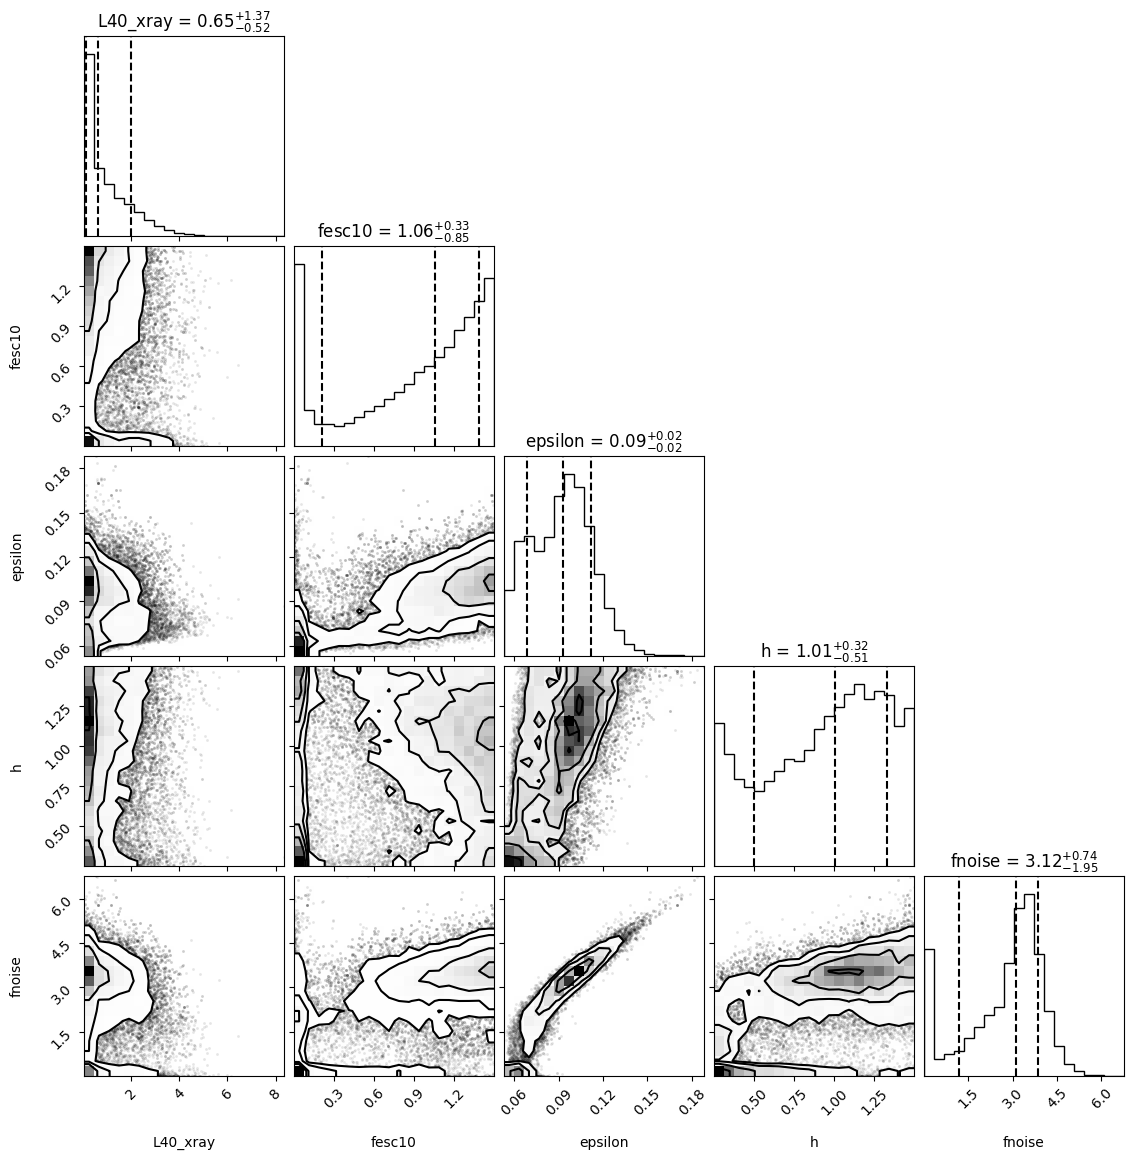

In [123]:

nre_results = build_sampler(
        model=nre_model,
        processed=processed,
        p_obs=observation['power'],
        domains=unscaled_feature_domains,
        nlive=1500,
        scaler = x_scaler,
    )
fig, samples = plot_corner(nre_results)